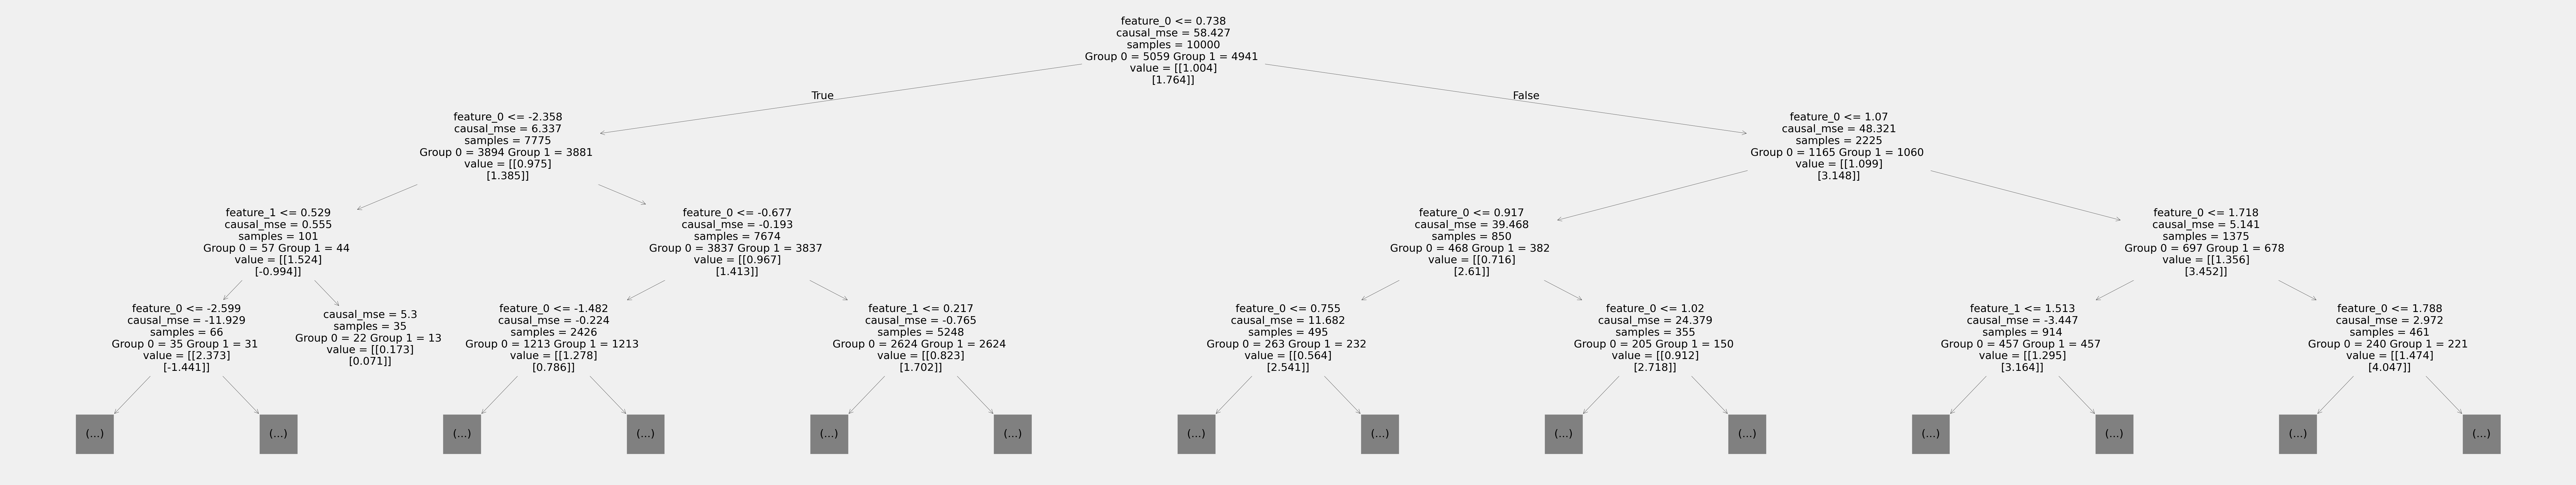

User condition: feature_2 <= 2.33 AND feature_4 <= 0.62 Selectivity: 0.7255
Total subgroups: 502 Valid subgroups: 340
Pruned due to min rows: 162
Pruned due to not being subsets: 0


100%|██████████| 340/340 [00:01<00:00, 206.71it/s]


In [1]:
%load_ext autoreload
%autoreload 2

from trees.causal_tree import CT
from trees.scanners import *
from trees.data import Data

D = Data()
D.generate(seed=2)
alg = CT()
alg.fit(D=D)
alg.plot_tree(max_depth=3)
D.generate_random_condition()
alg.online()
scan = Weighted(alg)
top = scan.get_topK()

In [ ]:

sum_hops = np.zeros(10)
n_hops = np.zeros(10)

for i, ov in enumerate(scan.op_matrix):
    for j, o in enumerate(ov):
        if o > 0:
            if j in alg.subgroups[i]['parents']:
                dist = len(alg.subgroups[i]['parents']) - alg.subgroups[i]['parents'].index(j)
                # print(len(alg.subgroups[i]['parents']), alg.subgroups[i]['parents'].index(j), o)
                # print(dist, o)
                

            elif i in alg.subgroups[j]['parents']:
                dist = len(alg.subgroups[j]['parents']) - alg.subgroups[j]['parents'].index(i)
                # print(len(alg.subgroups[j]['parents']), alg.subgroups[j]['parents'].index(i), o)
                # print(dist, o)
            
            if dist<10:
                sum_hops[dist] += o
                n_hops[dist] += 1

sum_hops/=n_hops
sum_hops

# plot sum_hops


array([       nan, 0.56493341, 0.37414025, 0.26772395, 0.20172745,
       0.15881616, 0.13122841, 0.11199346, 0.09871673, 0.08676849])

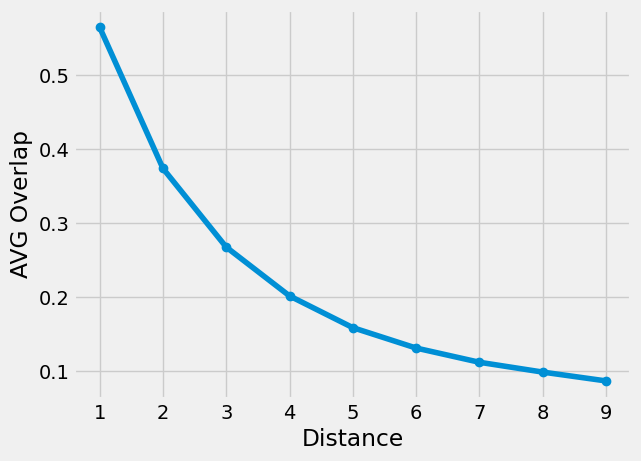

In [10]:
import numpy as np

import matplotlib.pyplot as plt

# Plot sum_hops
plt.plot(np.arange(10), sum_hops, marker='o')
plt.xlabel('Distance')
plt.ylabel('AVG Overlap')
plt.grid(True)
plt.show()